# Imports and definitions

In [2]:
# imports
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import simpson
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.cm as cm
from numpy import sqrt
import numpy as np
import os

In [3]:
# display dynamical plots
%matplotlib widget

In [4]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Fetch data

In [15]:
sd       = SimDir("../simulations/Merger_CCZ4_M=1,1-T=0.1,0.1-alpha=0,1.5pi-x0=8_h=3")
ts       = sd.timeseries
gf       = sd.gf
hc_norm  = ts.norm2["H"]
Ec_norm  = ts.norm2["Ec"]
Bc_norm  = ts.norm2["Bc"]
mcx_norm = ts.norm2["M1"]
mcy_norm = ts.norm2["M2"]
mcz_norm = ts.norm2["M3"]
label    = "base"

sd_2       = SimDir("../simulations/test/Merger_ccz4_M=1,1-T=0.1,0.1-alpha=0,1.5pi-x0=8_no-diss-last-lvl_h=3")
ts_2       = sd_2.timeseries
gf_2       = sd_2.gf
hc_norm_2  = ts_2.norm2["H"]
Ec_norm_2  = ts_2.norm2["Ec"]
Bc_norm_2  = ts_2.norm2["Bc"]
mcx_norm_2 = ts_2.norm2["M1"]
mcy_norm_2 = ts_2.norm2["M2"]
mcz_norm_2 = ts_2.norm2["M3"]
label_2    = "no diss last lvl"

sd_3       = SimDir("../simulations/test/Merger_ccz4_M=1,1-T=0.1,0.1-alpha=0,1.5pi-x0=8_big-boundaries_h=3")
ts_3       = sd_3.timeseries
gf_3       = sd_3.gf
hc_norm_3  = ts_3.norm2["H"]
Ec_norm_3  = ts_3.norm2["Ec"]
Bc_norm_3  = ts_3.norm2["Bc"]
mcx_norm_3 = ts_3.norm2["M1"]
mcy_norm_3 = ts_3.norm2["M2"]
mcz_norm_3 = ts_3.norm2["M3"]
label_3    = "big boundaries"

sd_4       = SimDir("../simulations/test/Merger_ccz4_M=1,1-T=0.1,0.1-alpha=0,1.5pi-x0=8_kappa=2_h=3")
ts_4       = sd_4.timeseries
gf_4       = sd_4.gf
hc_norm_4  = ts_4.norm2["H"]
Ec_norm_4  = ts_4.norm2["Ec"]
Bc_norm_4  = ts_4.norm2["Bc"]
mcx_norm_4 = ts_4.norm2["M1"]
mcy_norm_4 = ts_4.norm2["M2"]
mcz_norm_4 = ts_4.norm2["M3"]
label_4    = r"$\kappa = 2$"

sd_5       = SimDir("../simulations/test/Merger_ccz4_M=1,1-T=0.1,0.1-alpha=0,1.5pi-x0=8_eps=0.15_h=3")
ts_5       = sd_5.timeseries
gf_5       = sd_5.gf
hc_norm_5  = ts_5.norm2["H"]
Ec_norm_5  = ts_5.norm2["Ec"]
Bc_norm_5  = ts_5.norm2["Bc"]
mcx_norm_5 = ts_5.norm2["M1"]
mcy_norm_5 = ts_5.norm2["M2"]
mcz_norm_5 = ts_5.norm2["M3"]
label_5    = r"$\epsilon = 0.15$"

sd_6       = SimDir("../simulations/test/Merger_CCZ4_M=1,1-T=0.1,0.1-alpha=0,1.5pi-x0=8_dtfac=0.2_h=3")
ts_6       = sd_6.timeseries
gf_6       = sd_6.gf
hc_norm_6  = ts_6.norm2["H"]
Ec_norm_6  = ts_6.norm2["Ec"]
Bc_norm_6  = ts_6.norm2["Bc"]
mcx_norm_6 = ts_6.norm2["M1"]
mcy_norm_6 = ts_6.norm2["M2"]
mcz_norm_6 = ts_6.norm2["M3"]
label_6    = r"dtfac=0.2"

# Constraints

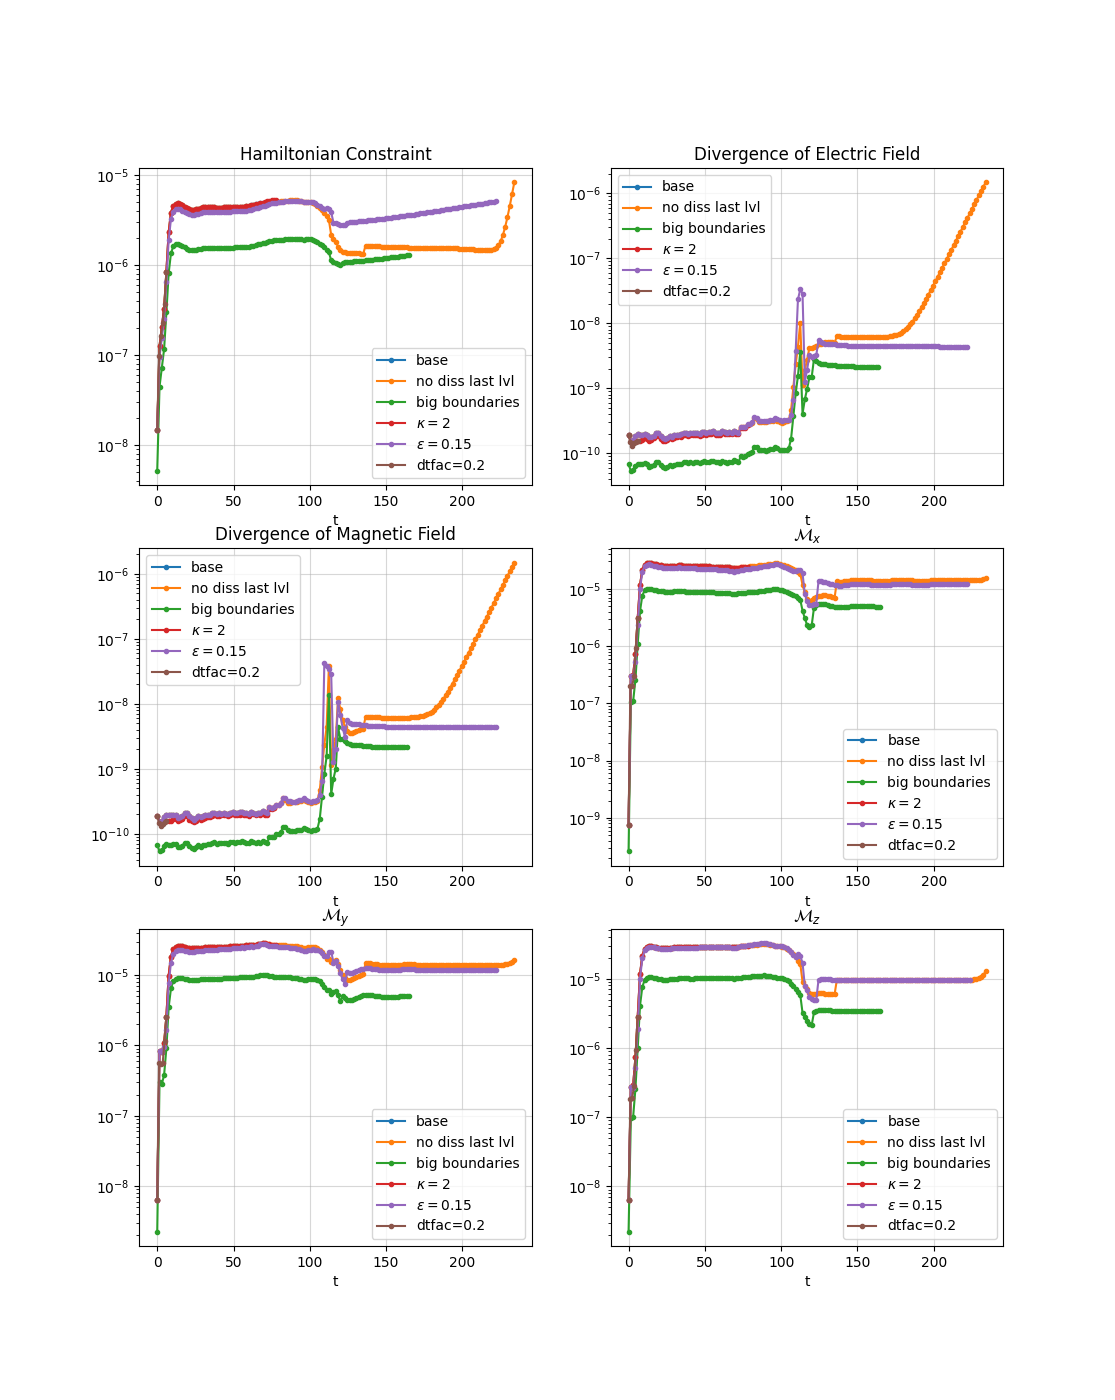

In [16]:
fig, ax = plt.subplots(3, 2, figsize=(11.15,14))


ax[0,0].plot(hc_norm.t,   hc_norm.y,   marker=".", label=label  )
ax[0,0].plot(hc_norm_2.t, hc_norm_2.y, marker=".", label=label_2)
ax[0,0].plot(hc_norm_3.t, hc_norm_3.y, marker=".", label=label_3)
ax[0,0].plot(hc_norm_4.t, hc_norm_4.y, marker=".", label=label_4)
ax[0,0].plot(hc_norm_5.t, hc_norm_5.y, marker=".", label=label_5)
ax[0,0].plot(hc_norm_6.t, hc_norm_6.y, marker=".", label=label_6)

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,   Ec_norm.y,   marker=".", label=label  )
ax[0,1].plot(Ec_norm_2.t, Ec_norm_2.y, marker=".", label=label_2)
ax[0,1].plot(Ec_norm_3.t, Ec_norm_3.y, marker=".", label=label_3)
ax[0,1].plot(Ec_norm_4.t, Ec_norm_4.y, marker=".", label=label_4)
ax[0,1].plot(Ec_norm_5.t, Ec_norm_5.y, marker=".", label=label_5)
ax[0,1].plot(Ec_norm_6.t, Ec_norm_6.y, marker=".", label=label_6)

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,   Bc_norm.y,   marker=".", label=label  )
ax[1,0].plot(Bc_norm_2.t, Bc_norm_2.y, marker=".", label=label_2)
ax[1,0].plot(Bc_norm_3.t, Bc_norm_3.y, marker=".", label=label_3)
ax[1,0].plot(Bc_norm_4.t, Bc_norm_4.y, marker=".", label=label_4)
ax[1,0].plot(Bc_norm_5.t, Bc_norm_5.y, marker=".", label=label_5)
ax[1,0].plot(Bc_norm_6.t, Bc_norm_6.y, marker=".", label=label_6)

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();


ax[1,1].plot(mcx_norm.t,   mcx_norm.y,   marker=".", label=label  )
ax[1,1].plot(mcx_norm_2.t, mcx_norm_2.y, marker=".", label=label_2)
ax[1,1].plot(mcx_norm_3.t, mcx_norm_3.y, marker=".", label=label_3)
ax[1,1].plot(mcx_norm_4.t, mcx_norm_4.y, marker=".", label=label_4)
ax[1,1].plot(mcx_norm_5.t, mcx_norm_5.y, marker=".", label=label_5)
ax[1,1].plot(mcx_norm_6.t, mcx_norm_6.y, marker=".", label=label_6)

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_yscale("log")
ax[1,1].set_title(r"$\mathcal{M}_x$")
ax[1,1].legend();


ax[2,0].plot(mcy_norm.t,   mcy_norm.y,   marker=".", label=label  )
ax[2,0].plot(mcy_norm_2.t, mcy_norm_2.y, marker=".", label=label_2)
ax[2,0].plot(mcy_norm_3.t, mcy_norm_3.y, marker=".", label=label_3)
ax[2,0].plot(mcy_norm_4.t, mcy_norm_4.y, marker=".", label=label_4)
ax[2,0].plot(mcy_norm_5.t, mcy_norm_5.y, marker=".", label=label_5)
ax[2,0].plot(mcy_norm_6.t, mcy_norm_6.y, marker=".", label=label_6)

ax[2,0].grid(alpha=0.5)
ax[2,0].set_xlabel("t")
ax[2,0].set_yscale("log")
ax[2,0].set_title(r"$\mathcal{M}_y$")
ax[2,0].legend();


ax[2,1].plot(mcz_norm.t,   mcz_norm.y,   marker=".", label=label  )
ax[2,1].plot(mcz_norm_2.t, mcz_norm_2.y, marker=".", label=label_2)
ax[2,1].plot(mcz_norm_3.t, mcz_norm_3.y, marker=".", label=label_3)
ax[2,1].plot(mcz_norm_4.t, mcz_norm_4.y, marker=".", label=label_4)
ax[2,1].plot(mcz_norm_5.t, mcz_norm_5.y, marker=".", label=label_5)
ax[2,1].plot(mcz_norm_6.t, mcz_norm_6.y, marker=".", label=label_6)

ax[2,1].grid(alpha=0.5)
ax[2,1].set_xlabel("t")
ax[2,1].set_yscale("log")
ax[2,1].set_title(r"$\mathcal{M}_z$")
ax[2,1].legend();

# EM Field

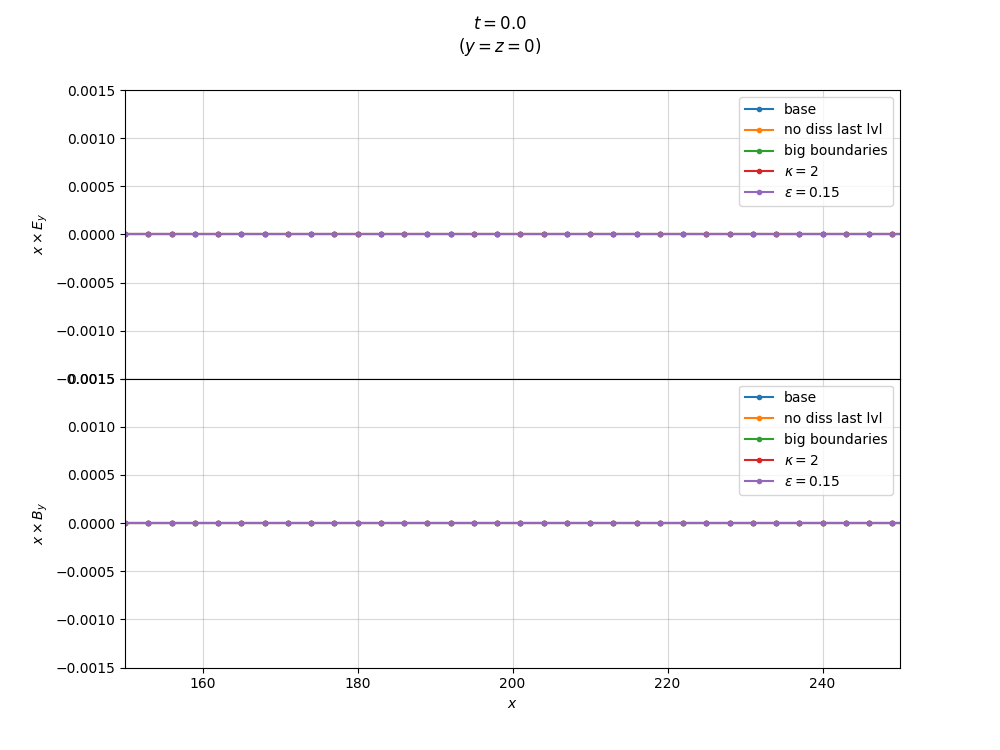

In [ ]:
# we have different dtfac's here
# every 6 units of time they match
n = 0
time = 6*n


Ey_gf = gf.x["Ey"].get_time(time).get_level(0)
coor  = Ey_gf.grid.coordinates_1d[0]
Ey    = Ey_gf.data

Ey_gf_2 = gf_2.x["Ey"].get_time(time).get_level(0)
coor_2  = Ey_gf_2.grid.coordinates_1d[0]
Ey_2    = Ey_gf_2.data

Ey_gf_3 = gf_3.x["Ey"].get_time(time).get_level(0)
coor_3  = Ey_gf_3.grid.coordinates_1d[0]
Ey_3    = Ey_gf_3.data

Ey_gf_4 = gf_4.x["Ey"].get_time(time).get_level(0)
coor_4  = Ey_gf_4.grid.coordinates_1d[0]
Ey_4    = Ey_gf_4.data

Ey_gf_5 = gf_5.x["Ey"].get_time(time).get_level(0)
coor_5  = Ey_gf_5.grid.coordinates_1d[0]
Ey_5    = Ey_gf_5.data


By_gf = gf.x["By"].get_time(time).get_level(0)
coor  = By_gf.grid.coordinates_1d[0]
By    = By_gf.data

By_gf_2 = gf_2.x["By"].get_time(time).get_level(0)
coor_2  = By_gf_2.grid.coordinates_1d[0]
By_2    = By_gf_2.data

By_gf_3 = gf_3.x["By"].get_time(time).get_level(0)
coor_3  = By_gf_3.grid.coordinates_1d[0]
By_3    = By_gf_3.data

By_gf_4 = gf_4.x["By"].get_time(time).get_level(0)
coor_4  = By_gf_4.grid.coordinates_1d[0]
By_4    = By_gf_4.data

By_gf_5 = gf_5.x["By"].get_time(time).get_level(0)
coor_5  = By_gf_5.grid.coordinates_1d[0]
By_5    = By_gf_5.data


fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10,7.5), sharex=True, gridspec_kw={'hspace': 0})

plt.suptitle(f"$t = {Ey_gf.time}$\n$(y=z=0)$")

# plot the electric field
ax1.plot(coor,   coor*Ey,     color="C0", label=label,   marker=".")
ax1.plot(coor_2, coor_2*Ey_2, color="C1", label=label_2, marker=".")
ax1.plot(coor_3, coor_3*Ey_3, color="C2", label=label_3, marker=".")
ax1.plot(coor_4, coor_4*Ey_4, color="C3", label=label_4, marker=".")
ax1.plot(coor_5, coor_5*Ey_5, color="C4", label=label_5, marker=".")

ax1.grid(alpha=0.5)
ax1.set_ylabel(r"$x \times E_y$")
ax1.set_ylim((-0.0015,0.0015))
ax1.legend()

# plot the magnetic field
ax2.plot(coor,   coor*By,     color="C0", label=label,   marker=".")
ax2.plot(coor_2, coor_2*By_2, color="C1", label=label_2, marker=".")
ax2.plot(coor_3, coor_3*By_3, color="C2", label=label_3, marker=".")
ax2.plot(coor_4, coor_4*By_4, color="C3", label=label_4, marker=".")
ax2.plot(coor_5, coor_5*By_5, color="C4", label=label_5, marker=".")

ax2.grid(alpha=0.5)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$x \times B_y$")
ax2.set_xlim((150,250))
ax2.set_ylim((-0.0015,0.0015))
ax2.legend();